In [1]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import os

In [2]:
if not os.path.exists('yolov3.weights'):
    !wget https://pjreddie.com/media/files/yolov3.weights
if not os.path.exists('yolov3.cfg'):
    !wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
if not os.path.exists('coco.names'):
    !wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2025-04-03 15:40:55--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  12.8MB/s    in 17s     

2025-04-03 15:41:13 (13.8 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2025-04-03 15:41:13--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0.001s  

2

In [3]:
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

In [4]:
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Function to detect objects (with option for NMS)
def detect_objects(image_path, use_nms=True):
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, channels = img.shape

    blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    class_ids = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    img_with_nms = img.copy()
    img_without_nms = img.copy()

    colors = np.random.uniform(0, 255, size=(len(classes), 3))
    font = cv2.FONT_HERSHEY_PLAIN
    for i in range(len(boxes)):
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        confidence = confidences[i]
        color = colors[class_ids[i]]
        cv2.rectangle(img_without_nms, (x, y), (x + w, y + h), color, 2)
        cv2.putText(img_without_nms, f"{label} {confidence:.2f}", (x, y - 10), font, 1, color, 2)

    if use_nms:
        indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
        for i in range(len(boxes)):
            if i in indexes:
                x, y, w, h = boxes[i]
                label = str(classes[class_ids[i]])
                confidence = confidences[i]
                color = colors[class_ids[i]]
                cv2.rectangle(img_with_nms, (x, y), (x + w, y + h), color, 2)
                cv2.putText(img_with_nms, f"{label} {confidence:.2f}", (x, y - 10), font, 1, color, 2)
    else:
        img_with_nms = img_without_nms.copy()

    return img_without_nms, img_with_nms

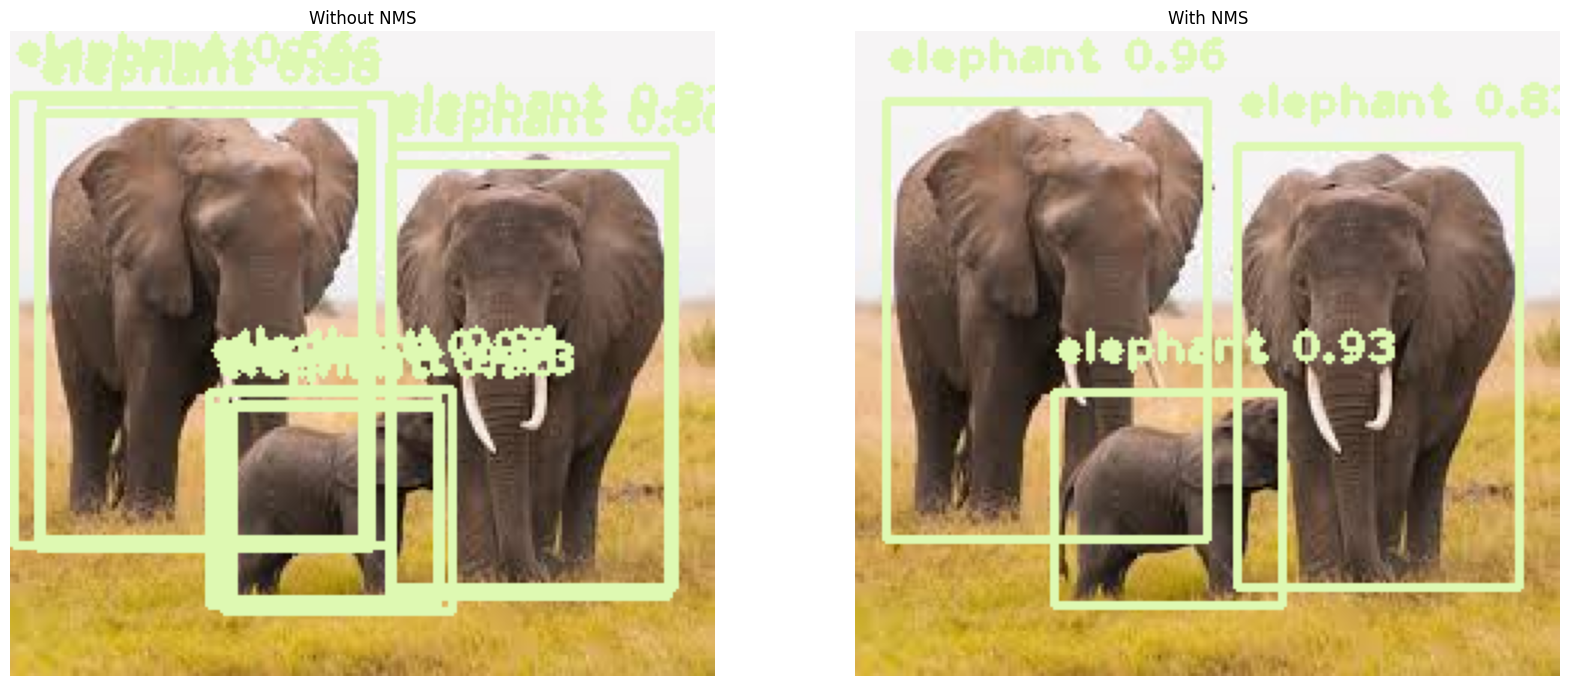

In [5]:
image_path = "/content/q2.jpeg"

# Get results with and without NMS
img_without_nms, img_with_nms = detect_objects(image_path, use_nms=True)

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_without_nms)
plt.title('Without NMS')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_with_nms)
plt.title('With NMS')
plt.axis('off')

plt.show()